In [92]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [93]:
def connect_db(db_file = "../data/trader_bro.db") -> sqlite3.Connection:
    return sqlite3.connect(db_file)

In [94]:
def get_database_entries(db_file="../data/trader_bro.db") -> pd.DataFrame:
    conn = connect_db(db_file)
    df = pd.read_sql_query(
        "SELECT id, timestamp, product_id, decision, price, amount_usd, status, input_tokens, output_tokens FROM decisions",
        conn,
    )
    conn.close()
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    return df

In [95]:
df = get_database_entries()
print(f"Total decisions: {len(df):,}  |  Date range: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
df.head()

Total decisions: 4,087  |  Date range: 2026-03-11 → 2026-04-26


,id,timestamp,product_id,decision,price,amount_usd,status,input_tokens,output_tokens
0,1,2026-03-11 20:20:23.877016+00:00,BTC-USD,HOLD,70496.10500,0.0,skipped,0,0
1,2,2026-03-11 20:21:00.676586+00:00,ETH-USD,HOLD,2070.96500,0.0,skipped,0,0
2,3,2026-03-11 20:21:32.777877+00:00,SOL-USD,HOLD,87.17500,0.0,skipped,0,0
3,4,2026-03-11 20:22:03.382301+00:00,DOGE-USD,HOLD,0.09352,0.0,skipped,0,0
4,5,2026-03-11 20:22:40.833488+00:00,ADA-USD,HOLD,0.26435,0.0,skipped,0,0


## P&L Analysis Setup (FIFO Engine)

In [96]:
COINBASE_FEE_RATE = 0.006  # 0.6% taker fee per fill (Coinbase Advanced Trade)

def run_fifo_pnl(df, fee_rate=COINBASE_FEE_RATE):
    """Match BUY→SELL pairs using FIFO per product, deduct fees both sides."""
    filled = (
        df[df["status"] == "filled"].copy()
        .sort_values(["product_id", "timestamp"])
        .reset_index(drop=True)
    )
    filled["quantity"] = filled["amount_usd"] / filled["price"]

    realized_rows = []
    open_rows = []

    for pid, grp in filled.groupby("product_id"):
        buy_queue = []
        for _, row in grp.iterrows():
            if row["decision"] == "BUY":
                buy_queue.append({
                    "product_id":    pid,
                    "qty_remaining": row["quantity"],
                    "buy_price":     row["price"],
                    "buy_usd":       row["amount_usd"],
                    "buy_fee":       row["amount_usd"] * fee_rate,
                    "buy_ts":        row["timestamp"],
                    "buy_id":        row["id"],
                })
            elif row["decision"] == "SELL" and buy_queue:
                sell_qty = row["quantity"]
                sell_fee_total = row["amount_usd"] * fee_rate
                remaining = sell_qty
                while remaining > 1e-9 and buy_queue:
                    b = buy_queue[0]
                    matched = min(b["qty_remaining"], remaining)
                    bf = b["qty_remaining"] / (b["buy_usd"] / b["buy_price"]) if b["buy_price"] else 0
                    buy_fraction  = matched / b["qty_remaining"] if b["qty_remaining"] > 0 else 0
                    sell_fraction = matched / sell_qty if sell_qty > 0 else 0
                    buy_cost  = matched * b["buy_price"]
                    buy_fee   = b["buy_fee"] * buy_fraction
                    sell_rev  = matched * row["price"]
                    sell_fee  = sell_fee_total * sell_fraction
                    realized_rows.append({
                        "product_id":   pid,
                        "buy_ts":       b["buy_ts"],
                        "sell_ts":      row["timestamp"],
                        "buy_price":    b["buy_price"],
                        "sell_price":   row["price"],
                        "qty":          matched,
                        "buy_cost":     buy_cost,
                        "sell_rev":     sell_rev,
                        "buy_fee":      buy_fee,
                        "sell_fee":     sell_fee,
                        "total_fees":   buy_fee + sell_fee,
                        "realized_pnl": sell_rev - buy_cost - buy_fee - sell_fee,
                        "hold_hours":   (row["timestamp"] - b["buy_ts"]).total_seconds() / 3600,
                        "winning":      (sell_rev - buy_cost - buy_fee - sell_fee) > 0,
                    })
                    b["qty_remaining"] -= matched
                    remaining -= matched
                    if b["qty_remaining"] < 1e-9:
                        buy_queue.pop(0)
        for b in buy_queue:
            if b["qty_remaining"] > 1e-9:
                frac = b["qty_remaining"] / (b["buy_usd"] / b["buy_price"]) if b["buy_price"] else 0
                open_rows.append({
                    "product_id": pid,
                    "qty":        b["qty_remaining"],
                    "buy_price":  b["buy_price"],
                    "cost_usd":   b["qty_remaining"] * b["buy_price"],
                    "buy_fee":    b["buy_fee"] * (b["qty_remaining"] / (b["buy_usd"] / b["buy_price"])) if b["buy_price"] else 0,
                    "buy_ts":     b["buy_ts"],
                })

    realized_df = pd.DataFrame(realized_rows) if realized_rows else pd.DataFrame(
        columns=["product_id","buy_ts","sell_ts","buy_price","sell_price","qty",
                 "buy_cost","sell_rev","buy_fee","sell_fee","total_fees","realized_pnl","hold_hours","winning"])
    open_df = pd.DataFrame(open_rows) if open_rows else pd.DataFrame(
        columns=["product_id","qty","buy_price","cost_usd","buy_fee","buy_ts"])

    for col in ["sell_ts", "buy_ts"]:
        if col in realized_df.columns and not realized_df.empty:
            realized_df[col] = pd.to_datetime(realized_df[col], utc=True)

    return realized_df, open_df


realized_df, open_df = run_fifo_pnl(df)

conn_tmp = connect_db()
latest_prices = pd.read_sql_query("""
    SELECT product_id, price AS last_price
    FROM decisions d1
    WHERE timestamp = (
        SELECT MAX(timestamp) FROM decisions d2
        WHERE d2.product_id = d1.product_id
    )
""", conn_tmp)
conn_tmp.close()

if not open_df.empty:
    open_summary = (
        open_df.groupby("product_id")
        .agg(total_qty=("qty","sum"), avg_cost=("buy_price","mean"), cost_usd=("cost_usd","sum"))
        .reset_index()
        .merge(latest_prices, on="product_id", how="left")
    )
    open_summary["current_value"]  = open_summary["total_qty"] * open_summary["last_price"]
    open_summary["unrealized_pnl"] = open_summary["current_value"] - open_summary["cost_usd"]
    open_summary["unrealized_pct"] = (open_summary["unrealized_pnl"] / open_summary["cost_usd"] * 100).round(2)
else:
    open_summary = pd.DataFrame()

total_realized  = realized_df["realized_pnl"].sum() if not realized_df.empty else 0
total_fees      = realized_df["total_fees"].sum()   if not realized_df.empty else 0
total_cost_open = open_summary["cost_usd"].sum()    if not open_summary.empty else 0
total_unreal    = open_summary["unrealized_pnl"].sum() if not open_summary.empty else 0

print("FIFO engine complete.")
print(f"  Closed trade lots : {len(realized_df):,}")
print(f"  Open position lots: {len(open_df):,}")
print(f"  Realized P&L      : ${total_realized:,.2f}")
print(f"  Total fees paid   : ${total_fees:,.2f}")
print(f"  Open position cost: ${total_cost_open:,.2f}")
print(f"  Unrealized P&L    : ${total_unreal:,.2f}")

FIFO engine complete.
  Closed trade lots : 282
  Open position lots: 13
  Realized P&L      : $-244.55
  Total fees paid   : $363.34
  Open position cost: $926.57
  Unrealized P&L    : $3.21


## Decision Distribution

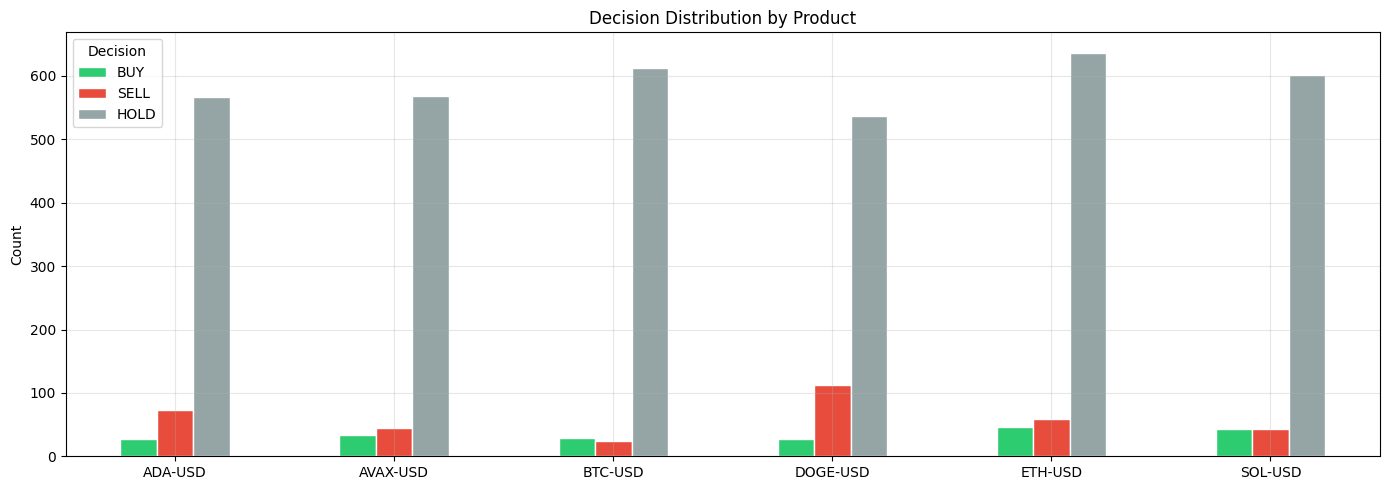

decision,BUY,SELL,HOLD
product_id,,,
ADA-USD,28,73,567
AVAX-USD,33,45,568
BTC-USD,29,24,613
DOGE-USD,28,113,537
ETH-USD,46,59,637
SOL-USD,43,43,601


In [97]:
decision_counts = df.groupby(["product_id", "decision"]).size().unstack(fill_value=0)
decision_counts = decision_counts.reindex(columns=["BUY", "SELL", "HOLD"], fill_value=0)

ax = decision_counts.plot(kind="bar", color=["#2ecc71", "#e74c3c", "#95a5a6"], edgecolor="white")
ax.set_title("Decision Distribution by Product")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.legend(title="Decision")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
decision_counts

## Order Status Breakdown

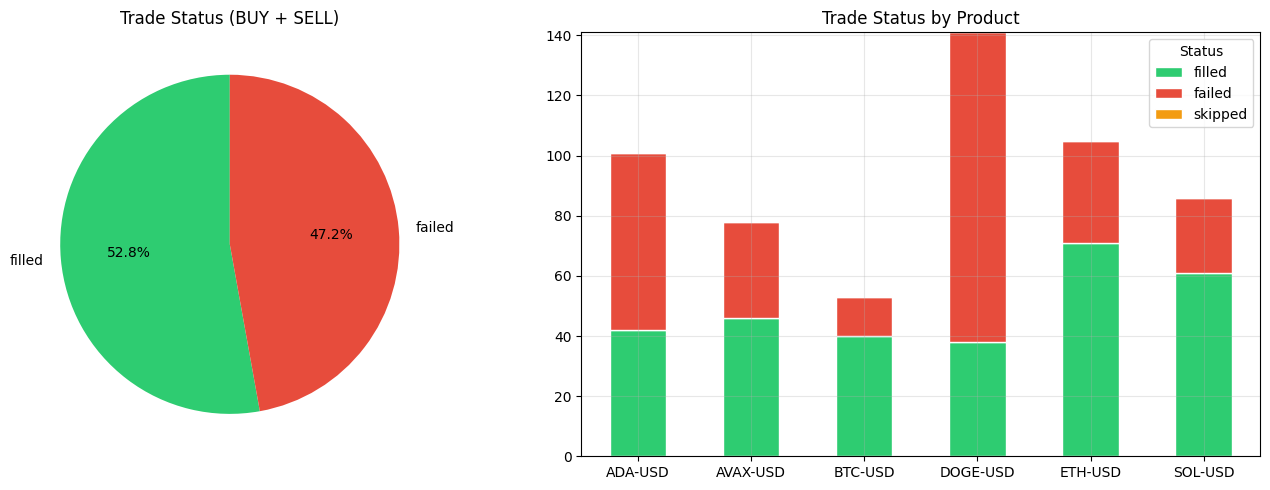

status      failed  filled
product_id                
ADA-USD         59      42
AVAX-USD        32      46
BTC-USD         13      40
DOGE-USD       103      38
ETH-USD         34      71
SOL-USD         25      61


In [98]:
trades = df[df["decision"] != "HOLD"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall status pie
status_counts = trades["status"].value_counts()
colors = {"filled": "#2ecc71", "failed": "#e74c3c", "skipped": "#f39c12"}
axes[0].pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    colors=[colors.get(s, "#bdc3c7") for s in status_counts.index],
    startangle=90,
)
axes[0].set_title("Trade Status (BUY + SELL)")

# Status by product stacked bar
status_by_product = trades.groupby(["product_id", "status"]).size().unstack(fill_value=0)
for s in ["filled", "failed", "skipped"]:
    if s not in status_by_product.columns:
        status_by_product[s] = 0
status_by_product[["filled", "failed", "skipped"]].plot(
    kind="bar", stacked=True,
    color=["#2ecc71", "#e74c3c", "#f39c12"],
    edgecolor="white", ax=axes[1],
)
axes[1].set_title("Trade Status by Product")
axes[1].set_xlabel("")
axes[1].legend(title="Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(trades.groupby(["product_id", "status"]).size().unstack(fill_value=0))

## Realized P&L by Product (FIFO, Fee-Adjusted)

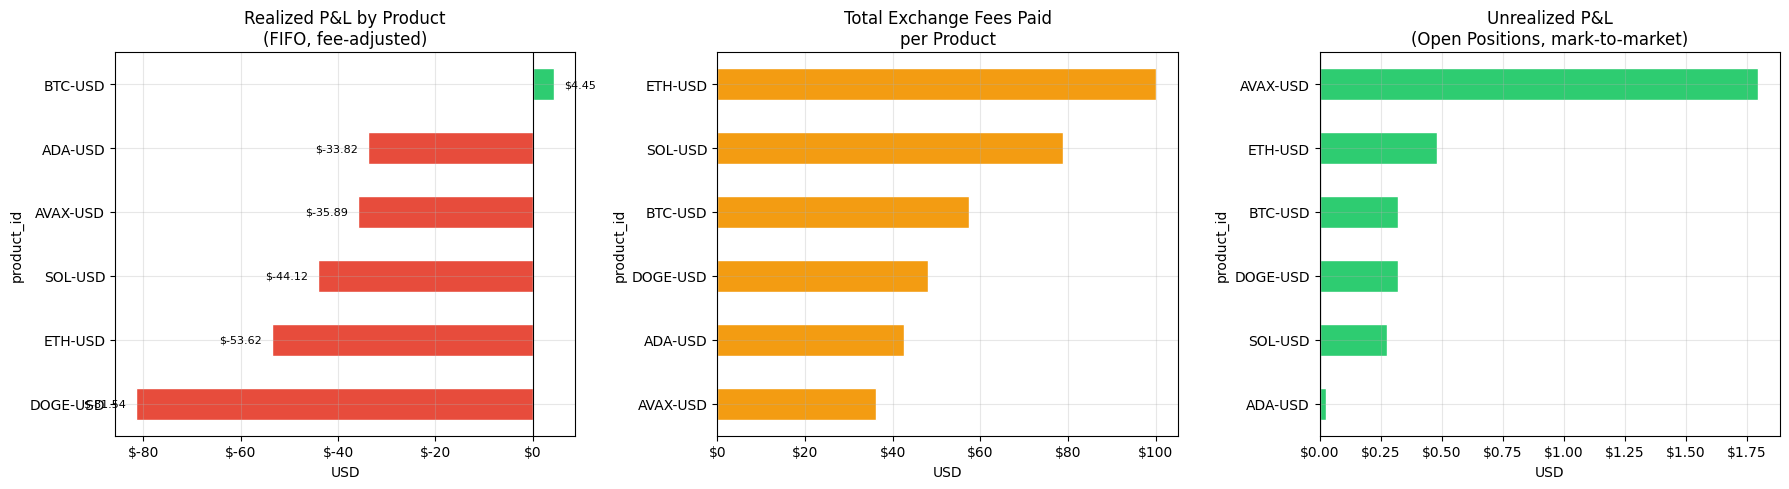

=== P&L SUMMARY ===
  Realized P&L (fee-adjusted): $   -244.55
  Total exchange fees paid:    $    363.34
  Open position cost basis:    $    926.57
  Unrealized P&L (mark-mkt):   $      3.21
  Net total (realized+unreal): $   -241.33

--- Per Product ---
            realized_pnl  total_fees  n_trades  cost_usd  unrealized_pnl
product_id                                                              
DOGE-USD          -81.54       47.97        36    276.17            0.32
ETH-USD           -53.62      100.05        70    132.73            0.48
SOL-USD           -44.12       78.98        58    174.84            0.28
AVAX-USD          -35.89       36.17        39    141.30            1.80
ADA-USD           -33.82       42.67        40    168.30            0.02
BTC-USD             4.45       57.49        39     33.23            0.32


In [99]:
pnl_by_product = (
    realized_df.groupby("product_id")
    .agg(realized_pnl=("realized_pnl","sum"), total_fees=("total_fees","sum"),
         n_trades=("realized_pnl","count"))
    .sort_values("realized_pnl")
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in pnl_by_product["realized_pnl"]]
pnl_by_product["realized_pnl"].plot(kind="barh", color=colors, edgecolor="white", ax=axes[0])
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Realized P&L by Product\n(FIFO, fee-adjusted)")
axes[0].set_xlabel("USD")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for bar, val in zip(axes[0].patches, pnl_by_product["realized_pnl"]):
    axes[0].text(val + (2 if val >= 0 else -2), bar.get_y() + bar.get_height() / 2,
                 f"${val:,.2f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)

pnl_by_product["total_fees"].sort_values().plot(
    kind="barh", color="#f39c12", edgecolor="white", ax=axes[1])
axes[1].set_title("Total Exchange Fees Paid\nper Product")
axes[1].set_xlabel("USD")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

if not open_summary.empty:
    ur = open_summary.set_index("product_id")["unrealized_pnl"].sort_values()
    ur_colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in ur]
    ur.plot(kind="barh", color=ur_colors, edgecolor="white", ax=axes[2])
    axes[2].axvline(0, color="black", linewidth=0.8)
    axes[2].set_title("Unrealized P&L\n(Open Positions, mark-to-market)")
    axes[2].set_xlabel("USD")
    axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.2f}"))

plt.tight_layout()
plt.show()

print("=== P&L SUMMARY ===")
print(f"  Realized P&L (fee-adjusted): ${total_realized:>10,.2f}")
print(f"  Total exchange fees paid:    ${total_fees:>10,.2f}")
print(f"  Open position cost basis:    ${total_cost_open:>10,.2f}")
print(f"  Unrealized P&L (mark-mkt):   ${total_unreal:>10,.2f}")
print(f"  Net total (realized+unreal): ${total_realized + total_unreal:>10,.2f}")
print()
print("--- Per Product ---")
disp = pnl_by_product.copy()
if not open_summary.empty:
    disp = disp.join(open_summary.set_index("product_id")[["cost_usd","unrealized_pnl"]], how="left").fillna(0)
print(disp.round(2).to_string())

## Cumulative P&L Over Time

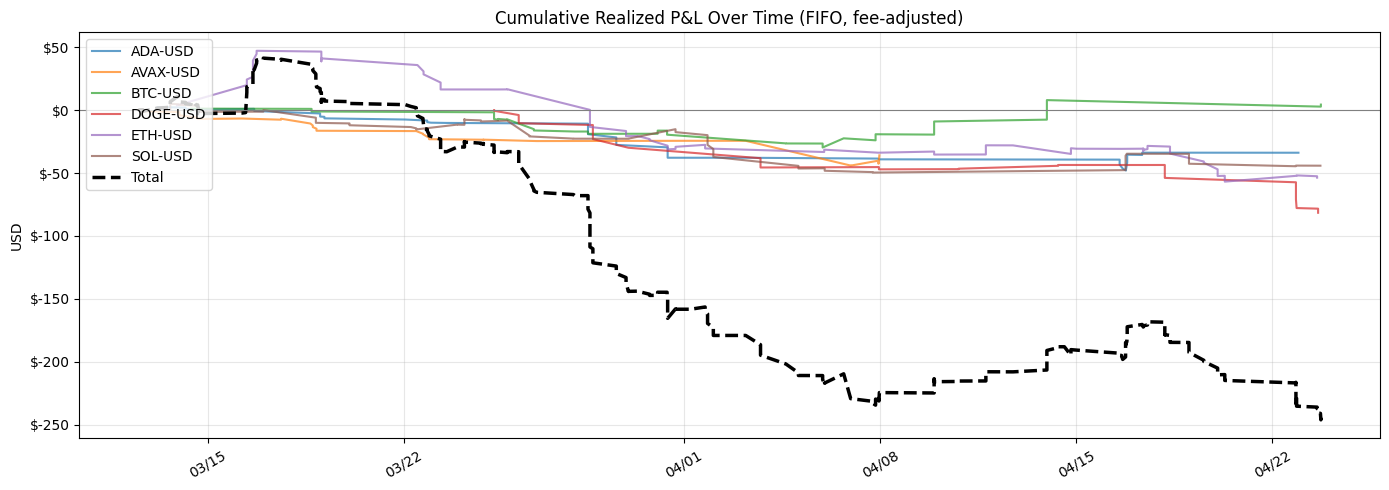

In [100]:
if realized_df.empty:
    print("No realized trades to plot.")
else:
    cum = realized_df.sort_values("sell_ts").copy()
    cum["cum_total"] = cum["realized_pnl"].cumsum()

    fig, ax = plt.subplots(figsize=(14, 5))
    for pid, grp in cum.groupby("product_id"):
        grp = grp.copy().sort_values("sell_ts")
        grp["cum_prod"] = grp["realized_pnl"].cumsum()
        ax.plot(grp["sell_ts"], grp["cum_prod"], label=pid, linewidth=1.5, alpha=0.7)

    ax.plot(cum["sell_ts"], cum["cum_total"],
            color="black", linewidth=2.5, label="Total", linestyle="--")
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_title("Cumulative Realized P&L Over Time (FIFO, fee-adjusted)")
    ax.set_ylabel("USD")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    ax.legend(loc="upper left")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## Trade Quality Metrics (Win Rate, Avg Profit/Loss, Hold Time)

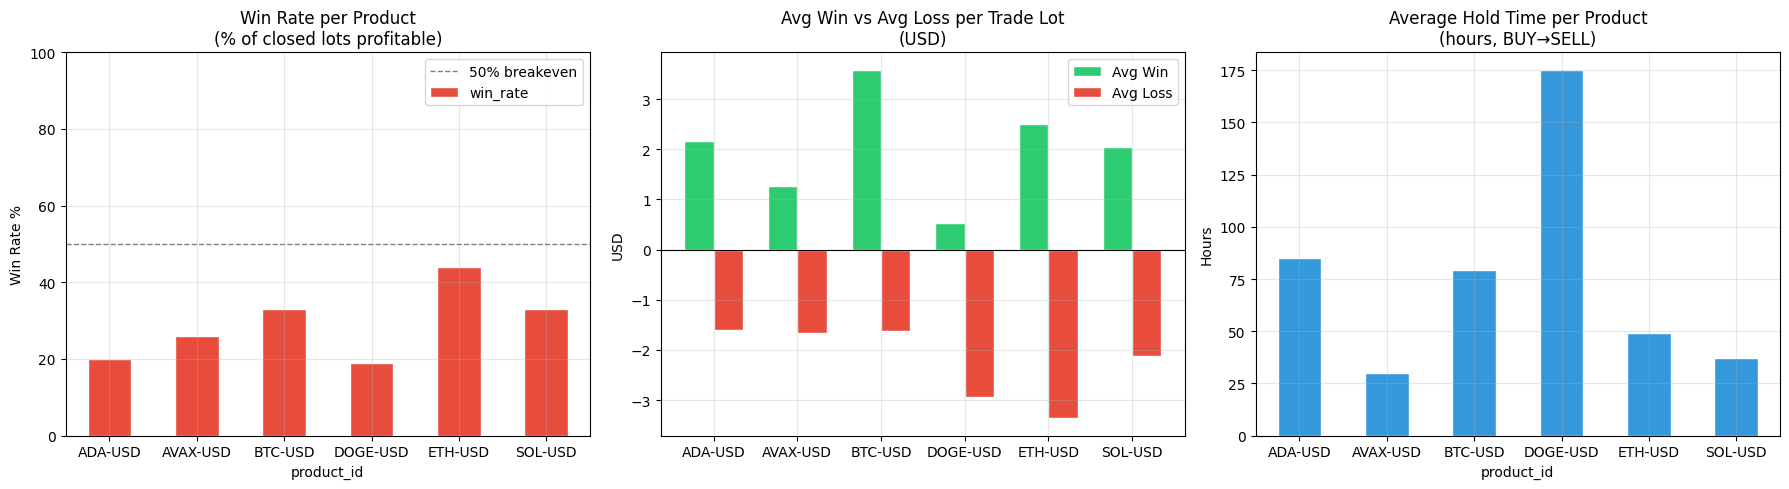

=== TRADE QUALITY METRICS ===
            n_closed  win_rate  avg_win_usd  avg_loss_usd  avg_hold_hrs  median_hold_h  total_fees
product_id                                                                                        
ADA-USD           40      0.20         2.17         -1.60         85.11          48.48       42.67
AVAX-USD          39      0.26         1.26         -1.67         29.78          17.28       36.17
BTC-USD           39      0.33         3.59         -1.62         79.21          65.12       57.49
DOGE-USD          36      0.19         0.54         -2.94        174.96         145.15       47.97
ETH-USD           70      0.44         2.50         -3.36         49.03          47.60      100.05
SOL-USD           58      0.33         2.04         -2.12         37.26          29.55       78.98

Profit factor (gross wins / gross losses): 0.45
  (>1.0 = winners outweigh losers in dollar terms)


In [101]:
if not realized_df.empty:
    metrics = realized_df.groupby("product_id").agg(
        n_closed      = ("realized_pnl", "count"),
        win_rate      = ("winning",       "mean"),
        avg_win_usd   = ("realized_pnl",  lambda x: x[x > 0].mean() if (x > 0).any() else 0),
        avg_loss_usd  = ("realized_pnl",  lambda x: x[x < 0].mean() if (x < 0).any() else 0),
        avg_hold_hrs  = ("hold_hours",    "mean"),
        median_hold_h = ("hold_hours",    "median"),
        total_fees    = ("total_fees",    "sum"),
    ).round(2)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    win_colors = ["#2ecc71" if v >= 0.5 else "#e74c3c" for v in metrics["win_rate"]]
    metrics["win_rate"].mul(100).plot(kind="bar", color=win_colors, edgecolor="white", ax=axes[0])
    axes[0].axhline(50, color="gray", linewidth=1, linestyle="--", label="50% breakeven")
    axes[0].set_title("Win Rate per Product\n(% of closed lots profitable)")
    axes[0].set_ylabel("Win Rate %")
    axes[0].set_ylim(0, 100)
    axes[0].legend()
    plt.setp(axes[0].get_xticklabels(), rotation=0)

    x = range(len(metrics))
    width = 0.35
    axes[1].bar([i - width/2 for i in x], metrics["avg_win_usd"],
                width=width, color="#2ecc71", edgecolor="white", label="Avg Win")
    axes[1].bar([i + width/2 for i in x], metrics["avg_loss_usd"],
                width=width, color="#e74c3c", edgecolor="white", label="Avg Loss")
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title("Avg Win vs Avg Loss per Trade Lot\n(USD)")
    axes[1].set_ylabel("USD")
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(metrics.index, rotation=0)
    axes[1].legend()

    metrics["avg_hold_hrs"].plot(kind="bar", color="#3498db", edgecolor="white", ax=axes[2])
    axes[2].set_title("Average Hold Time per Product\n(hours, BUY→SELL)")
    axes[2].set_ylabel("Hours")
    plt.setp(axes[2].get_xticklabels(), rotation=0)

    plt.tight_layout()
    plt.show()

    print("=== TRADE QUALITY METRICS ===")
    print(metrics.to_string())

    gross_wins = realized_df.loc[realized_df["winning"],  "realized_pnl"].sum()
    gross_loss = abs(realized_df.loc[~realized_df["winning"], "realized_pnl"].sum())
    profit_factor = gross_wins / gross_loss if gross_loss > 0 else float("inf")
    print(f"\nProfit factor (gross wins / gross losses): {profit_factor:.2f}")
    print("  (>1.0 = winners outweigh losers in dollar terms)")

## Open Positions (Unrealized / Inventory At Risk)

=== OPEN POSITIONS (coins still held) ===

product_id  total_qty   avg_cost  cost_usd  last_price  current_value  unrealized_pnl  unrealized_pct
   ADA-USD   662.5442     0.2535  168.2952       0.254       168.3194          0.0242            0.01
  AVAX-USD    15.0545     9.3190  141.2977       9.505       143.0928          1.7951            1.27
   BTC-USD     0.0004 77425.9950   33.2315   78171.305        33.5514          0.3199            0.96
  DOGE-USD  2793.5533     0.0981  276.1723       0.099       276.4919          0.3196            0.12
   ETH-USD     0.0570  2329.7950  132.7317    2338.205       133.2108          0.4791            0.36
   SOL-USD     2.0222    86.1175  174.8383      86.595       175.1153          0.2770            0.16

Total capital deployed in open positions: $926.57
Current mark-to-market value:             $929.78
Unrealized gain / (loss):                 $3.21


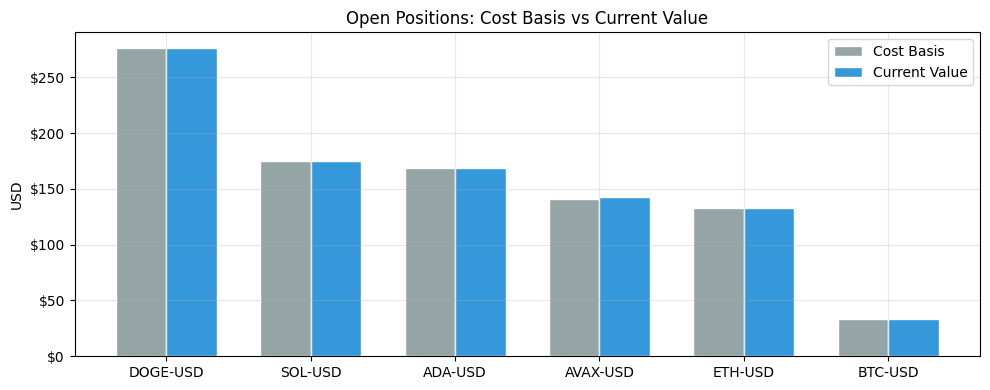

In [102]:
if not open_summary.empty:
    print("=== OPEN POSITIONS (coins still held) ===\n")
    display_cols = ["product_id","total_qty","avg_cost","cost_usd",
                    "last_price","current_value","unrealized_pnl","unrealized_pct"]
    print(open_summary[display_cols].round(4).to_string(index=False))
    print(f"\nTotal capital deployed in open positions: ${open_summary['cost_usd'].sum():,.2f}")
    print(f"Current mark-to-market value:             ${open_summary['current_value'].sum():,.2f}")
    print(f"Unrealized gain / (loss):                 ${open_summary['unrealized_pnl'].sum():,.2f}")

    fig, ax = plt.subplots(figsize=(10, 4))
    ur = open_summary.set_index("product_id")[["cost_usd","current_value"]].sort_values("cost_usd", ascending=False)
    x = range(len(ur))
    width = 0.35
    ax.bar([i - width/2 for i in x], ur["cost_usd"],     width=width, color="#95a5a6", edgecolor="white", label="Cost Basis")
    ax.bar([i + width/2 for i in x], ur["current_value"],width=width, color="#3498db", edgecolor="white", label="Current Value")
    ax.set_xticks(list(x))
    ax.set_xticklabels(ur.index, rotation=0)
    ax.set_title("Open Positions: Cost Basis vs Current Value")
    ax.set_ylabel("USD")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No open positions.")

## Trade Activity Over Time (Daily)

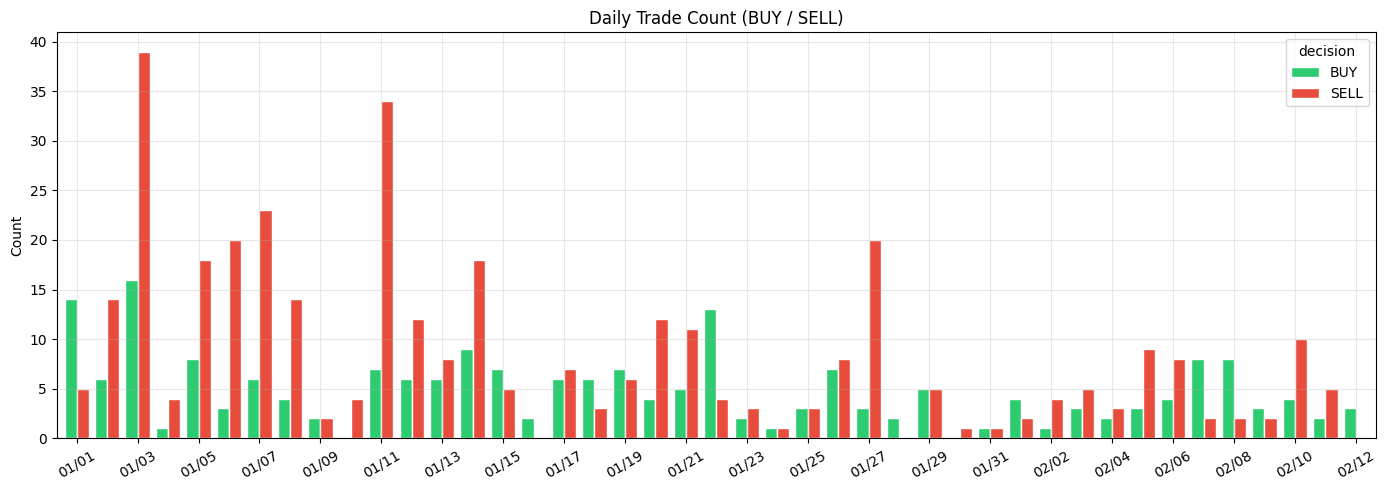

In [103]:
daily = (
    trades.set_index("timestamp")
    .groupby([pd.Grouper(freq="D"), "decision"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["BUY", "SELL"], fill_value=0)
)

ax = daily.plot(kind="bar", color=["#2ecc71", "#e74c3c"], edgecolor="white", width=0.8)
ax.set_title("Daily Trade Count (BUY / SELL)")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
# show fewer x-tick labels so they don't overlap
tick_step = max(1, len(daily) // 15)
ax.set_xticks(ax.get_xticks()[::tick_step])
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Price Target Accuracy (Bot Prediction Quality)

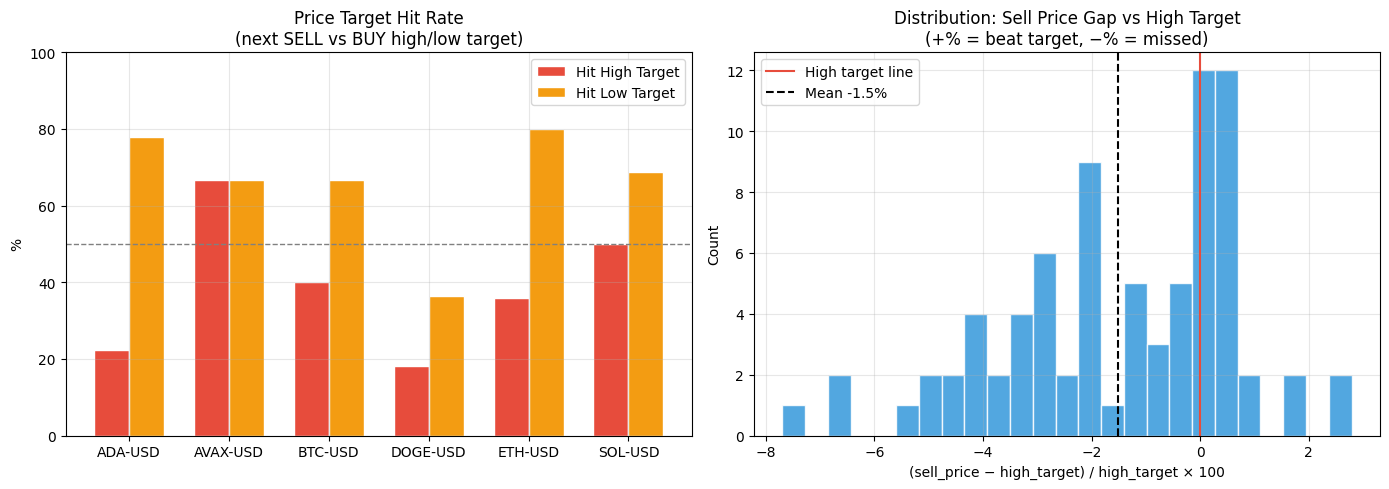

             n  pct_hit_high  pct_hit_low  avg_gap_pct
product_id                                            
ADA-USD      9         0.222        0.778       -2.450
AVAX-USD     3         0.667        0.667       -1.927
BTC-USD     15         0.400        0.667       -1.004
DOGE-USD    11         0.182        0.364       -2.215
ETH-USD     25         0.360        0.800       -1.515
SOL-USD     16         0.500        0.688       -0.910

Overall: 36.7% of next-sells reach the BUY high_target
Overall: 68.4% of next-sells reach the BUY low_target
Avg sell is -1.5% away from high target

Insight: if avg gap is negative, the bot is selling before reaching its own profit target.
Consider holding longer or raising the sell trigger threshold.


In [104]:
conn_pt = connect_db()
targets_df = pd.read_sql_query("""
    SELECT d.id AS decision_id, d.timestamp, d.product_id, d.decision,
           d.price AS trade_price, d.status, pt.low_target, pt.high_target
    FROM decisions d
    JOIN price_targets pt ON pt.decision_id = d.id
    WHERE d.status = 'filled' AND d.decision IN ('BUY','SELL')
    ORDER BY d.product_id, d.timestamp
""", conn_pt)
conn_pt.close()
targets_df["timestamp"] = pd.to_datetime(targets_df["timestamp"], utc=True)

if targets_df.empty:
    print("No price target data available yet.")
else:
    buy_targets = targets_df[targets_df["decision"] == "BUY"].copy()
    filled_sells = df[(df["decision"] == "SELL") & (df["status"] == "filled")].copy()
    filled_sells = filled_sells.sort_values(["product_id","timestamp"])

    rows = []
    for _, buy in buy_targets.iterrows():
        later = filled_sells[
            (filled_sells["product_id"] == buy["product_id"]) &
            (filled_sells["timestamp"]  > buy["timestamp"])
        ]
        if later.empty:
            continue
        ns = later.iloc[0]
        rows.append({
            "product_id":      buy["product_id"],
            "buy_price":       buy["trade_price"],
            "high_target":     buy["high_target"],
            "low_target":      buy["low_target"],
            "next_sell_price": ns["price"],
            "hit_low_target":  ns["price"] >= buy["low_target"],
            "hit_high_target": ns["price"] >= buy["high_target"],
            "gap_to_high_pct": (ns["price"] - buy["high_target"]) / buy["high_target"] * 100,
        })
    target_hits = pd.DataFrame(rows)

    if not target_hits.empty:
        hit_summary = (
            target_hits.groupby("product_id")
            .agg(n=("hit_high_target","count"),
                 pct_hit_high=("hit_high_target","mean"),
                 pct_hit_low =("hit_low_target","mean"),
                 avg_gap_pct =("gap_to_high_pct","mean"))
            .round(3)
        )

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        x = range(len(hit_summary))
        width = 0.35
        axes[0].bar([i - width/2 for i in x], hit_summary["pct_hit_high"] * 100,
                    width=width, color="#e74c3c", edgecolor="white", label="Hit High Target")
        axes[0].bar([i + width/2 for i in x], hit_summary["pct_hit_low"] * 100,
                    width=width, color="#f39c12", edgecolor="white", label="Hit Low Target")
        axes[0].axhline(50, color="gray", linewidth=1, linestyle="--")
        axes[0].set_xticks(list(x))
        axes[0].set_xticklabels(hit_summary.index, rotation=0)
        axes[0].set_title("Price Target Hit Rate\n(next SELL vs BUY high/low target)")
        axes[0].set_ylabel("%")
        axes[0].set_ylim(0, 100)
        axes[0].legend()

        axes[1].hist(target_hits["gap_to_high_pct"], bins=25,
                     color="#3498db", edgecolor="white", alpha=0.85)
        axes[1].axvline(0, color="#e74c3c", linewidth=1.5, label="High target line")
        axes[1].axvline(target_hits["gap_to_high_pct"].mean(), color="black",
                        linewidth=1.5, linestyle="--",
                        label=f"Mean {target_hits['gap_to_high_pct'].mean():.1f}%")
        axes[1].set_title("Distribution: Sell Price Gap vs High Target\n(+% = beat target, −% = missed)")
        axes[1].set_xlabel("(sell_price − high_target) / high_target × 100")
        axes[1].set_ylabel("Count")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        print(hit_summary.to_string())
        print(f"\nOverall: {target_hits['hit_high_target'].mean():.1%} of next-sells reach the BUY high_target")
        print(f"Overall: {target_hits['hit_low_target'].mean():.1%} of next-sells reach the BUY low_target")
        print(f"Avg sell is {target_hits['gap_to_high_pct'].mean():.1f}% away from high target")
        print("\nInsight: if avg gap is negative, the bot is selling before reaching its own profit target.")
        print("Consider holding longer or raising the sell trigger threshold.")

## Best Time to Trade (Hour-of-Day P&L Analysis)

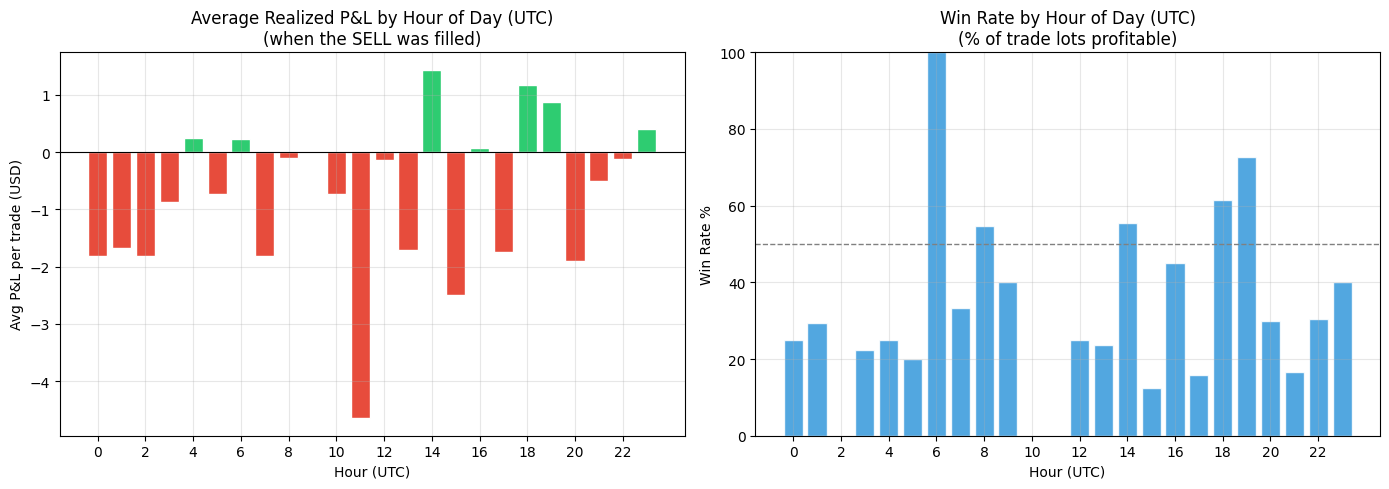

Best hours to trade (UTC, min 3 trades):
           n_trades  avg_pnl  win_rate
sell_hour                             
14                9    1.444     0.556
18               13    1.168     0.615
19               11    0.873     0.727
23               10    0.399     0.400
4                 4    0.253     0.250

Worst hours to trade (UTC, min 3 trades):
           n_trades  avg_pnl  win_rate
sell_hour                             
11                4   -4.647     0.000
15               24   -2.498     0.125
20               20   -1.898     0.300
7                 9   -1.815     0.333
2                11   -1.807     0.000

Product ranking by total realized P&L:
            total_pnl  win_rate  avg_pnl
product_id                              
BTC-USD          4.45      0.33     0.11
ADA-USD        -33.82      0.20    -0.85
AVAX-USD       -35.89      0.26    -0.92
SOL-USD        -44.12      0.33    -0.76
ETH-USD        -53.62      0.44    -0.77
DOGE-USD       -81.54      0.19    -2.27


In [105]:
if not realized_df.empty:
    hourly = realized_df.copy()
    hourly["sell_hour"] = hourly["sell_ts"].dt.hour

    hour_stats = hourly.groupby("sell_hour").agg(
        n_trades  = ("realized_pnl", "count"),
        total_pnl = ("realized_pnl", "sum"),
        avg_pnl   = ("realized_pnl", "mean"),
        win_rate  = ("winning",      "mean"),
    ).reindex(range(24), fill_value=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors_h = ["#2ecc71" if v >= 0 else "#e74c3c" for v in hour_stats["avg_pnl"]]
    axes[0].bar(hour_stats.index, hour_stats["avg_pnl"], color=colors_h, edgecolor="white")
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_title("Average Realized P&L by Hour of Day (UTC)\n(when the SELL was filled)")
    axes[0].set_xlabel("Hour (UTC)")
    axes[0].set_ylabel("Avg P&L per trade (USD)")
    axes[0].set_xticks(range(0, 24, 2))

    axes[1].bar(hour_stats.index, hour_stats["win_rate"] * 100,
                color="#3498db", edgecolor="white", alpha=0.85)
    axes[1].axhline(50, color="gray", linewidth=1, linestyle="--", label="50% line")
    axes[1].set_title("Win Rate by Hour of Day (UTC)\n(% of trade lots profitable)")
    axes[1].set_xlabel("Hour (UTC)")
    axes[1].set_ylabel("Win Rate %")
    axes[1].set_ylim(0, 100)
    axes[1].set_xticks(range(0, 24, 2))

    plt.tight_layout()
    plt.show()

    best_hours  = hour_stats[hour_stats["n_trades"] >= 3].nlargest(5,  "avg_pnl")
    worst_hours = hour_stats[hour_stats["n_trades"] >= 3].nsmallest(5, "avg_pnl")
    print("Best hours to trade (UTC, min 3 trades):")
    print(best_hours[["n_trades","avg_pnl","win_rate"]].round(3).to_string())
    print("\nWorst hours to trade (UTC, min 3 trades):")
    print(worst_hours[["n_trades","avg_pnl","win_rate"]].round(3).to_string())

    prod_stats = realized_df.groupby("product_id").agg(
        total_pnl=("realized_pnl","sum"),
        win_rate =("winning",     "mean"),
        avg_pnl  =("realized_pnl","mean"),
    ).round(2)
    print("\nProduct ranking by total realized P&L:")
    print(prod_stats.sort_values("total_pnl", ascending=False).to_string())

## Token Usage & Estimated Cost Over Time

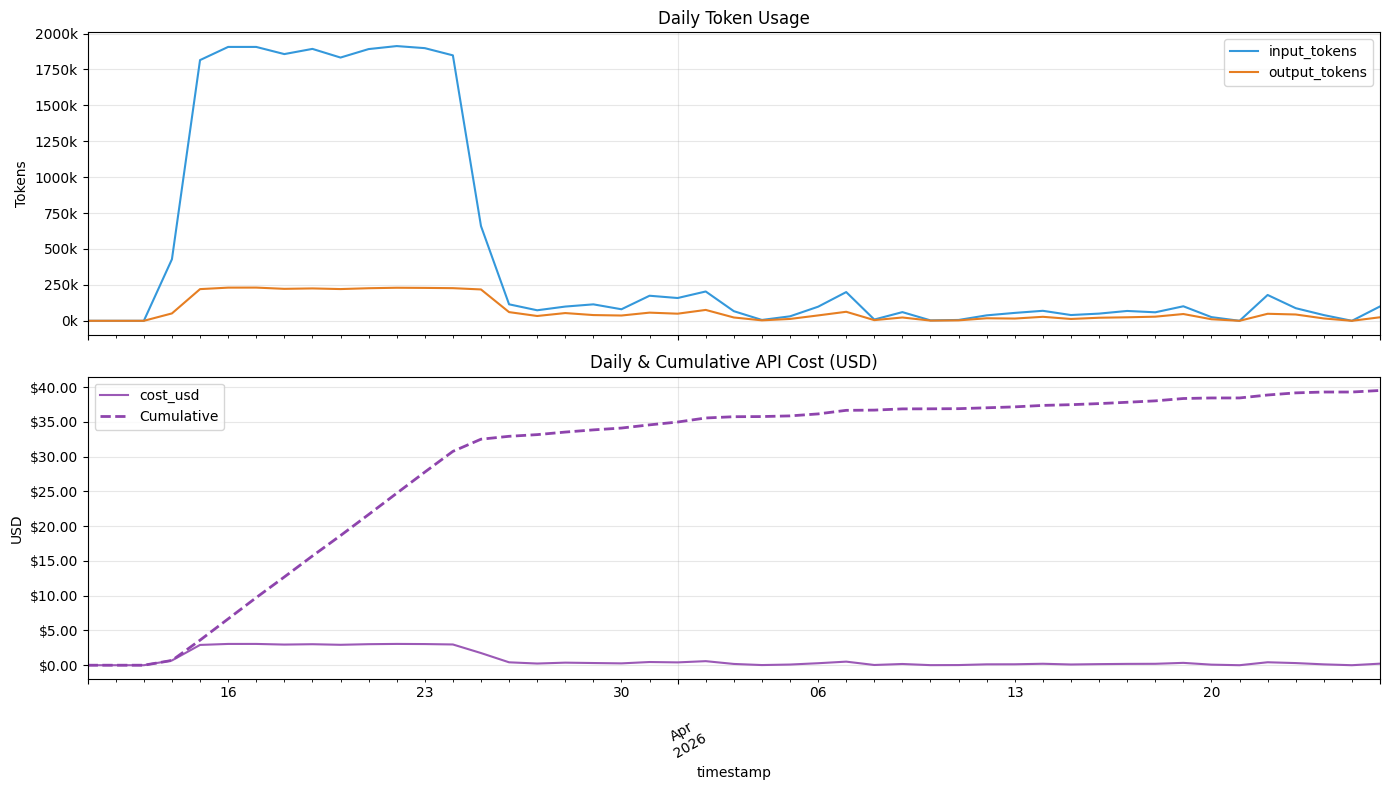

Total input tokens:  22,264,172
Total output tokens: 3,453,968
Total tokens:        25,718,140
Estimated total cost: $39.5340


In [106]:
# Claude Haiku 4.5 pricing (adjust if using a different model)
INPUT_COST_PER_M  = 1.00   # USD per 1M input tokens
OUTPUT_COST_PER_M = 5.00  # USD per 1M output tokens

df["cost_usd"] = (
    df["input_tokens"]  / 1_000_000 * INPUT_COST_PER_M +
    df["output_tokens"] / 1_000_000 * OUTPUT_COST_PER_M
)

token_daily = df.set_index("timestamp").resample("D")[["input_tokens", "output_tokens", "cost_usd"]].sum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

token_daily[["input_tokens", "output_tokens"]].plot(
    ax=ax1, color=["#3498db", "#e67e22"]
)
ax1.set_title("Daily Token Usage")
ax1.set_ylabel("Tokens")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

token_daily["cost_usd"].plot(ax=ax2, color="#9b59b6", linewidth=1.5)
token_daily["cost_usd"].cumsum().plot(ax=ax2, color="#8e44ad", linewidth=2, linestyle="--", label="Cumulative")
ax2.set_title("Daily & Cumulative API Cost (USD)")
ax2.set_ylabel("USD")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.2f}"))
ax2.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

total_tokens = df["input_tokens"].sum() + df["output_tokens"].sum()
total_cost = df["cost_usd"].sum()
print(f"Total input tokens:  {df['input_tokens'].sum():,}")
print(f"Total output tokens: {df['output_tokens'].sum():,}")
print(f"Total tokens:        {total_tokens:,}")
print(f"Estimated total cost: ${total_cost:.4f}")

## Trade Volume by Product

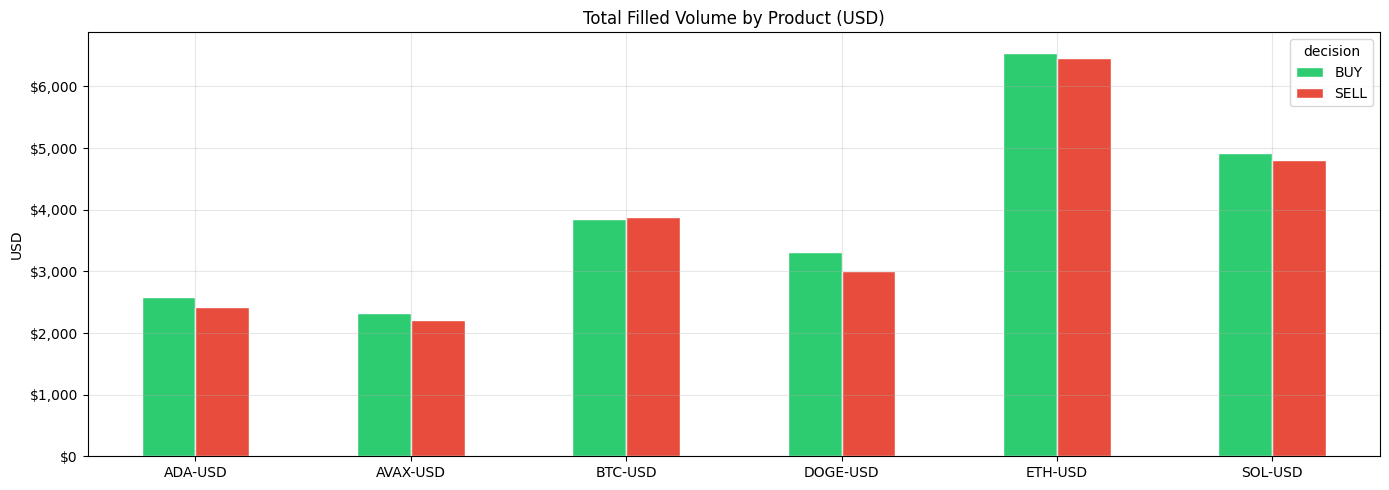

decision,BUY,SELL
product_id,,
ADA-USD,2587.19,2427.74133
AVAX-USD,2332.71,2207.84305
BTC-USD,3850.69,3879.40000
DOGE-USD,3314.80,3005.05500
ETH-USD,6550.89,6464.59000
SOL-USD,4919.24,4810.10000


In [107]:
filled = df[df["status"] == "filled"].copy()
vol = (
    filled.groupby(["product_id", "decision"])["amount_usd"]
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=["BUY", "SELL"], fill_value=0)
)

ax = vol.plot(kind="bar", color=["#2ecc71", "#e74c3c"], edgecolor="white")
ax.set_title("Total Filled Volume by Product (USD)")
ax.set_xlabel("")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
vol